# EDA 05 - Merged Analytical Dataset of Road closures and train moments

**Source**: Output of `geo.find_nearby_stations()` + `features.filter_within_time_window()`  
**Reads from**: `data/processed/road_closures_clean.parquet` + `data/processed/train_moments_clean.parquet`  
**Output**: `data/processed/road_train_moments_dataset.parquet`  consumed by `rail_delay_prediction.ipynb`

This notebook performs EDA on the merged analytical dataset that results from the spatial join (10-25 km haversine) and temporal filter (0-60 minute post-closure window). This is the dataset the model trains on. Exploring it here keeps the main analysis notebook focused purely on modelling.

---
**Sections**
1. Rebuild the analytical dataset from processed parquets  
2. Dataset overview and shape  
3. Delay (target variable) distribution  
4. Predictor distributions (distance, time)  
5. Categorical distributions (closure type, event type)  
6. Bivariate relationships (scatter, heatmap, correlation)  
7. Temporal patterns (hour of day, day of week)  
8. Spatial patterns (stations, closure impact)  
9. Save output  


## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_05", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

## 1. Rebuild Analytical Dataset

Rather than re-downloading from Azure, read the processed parquet files saved by EDA 02 and EDA 03, then re-run the spatial join and temporal filter. This keeps the EDA self-contained and fast.

In [2]:
from datetime import datetime, timezone
from src.geo import find_nearby_stations
from src.features import (
    merge_on_station, filter_within_time_window
)

# Load from processed parquets where available, else re-fetch
import os
stations_reference_path = "./data/processed/stations_reference.parquet"
road_path  = "./data/processed/road_closures_clean.parquet"
train_path = "./data/processed/train_moments_clean.parquet"

if os.path.exists(road_path) and os.path.exists(train_path):
    road_df  = pd.read_parquet(road_path)
    train_df = pd.read_parquet(train_path)
    stations_ref_df = pd.read_parquet(stations_reference_path)
    print(f"Loaded from parquet: {len(road_df):,} closures, {len(train_df):,} train moments, {len(stations_ref_df):,} stations")
else:
    print("Processed parquets not found - run EDA 01 and EDA 02 first.")
    raise FileNotFoundError("Missing processed parquets")

Loaded from parquet: 1,557 closures, 212,884 train moments, 2,594 stations


In [3]:
# Spatial join
expanded_road_df = find_nearby_stations(road_df, stations_ref_df, min_km=10, max_km=25)
print(f"Closure-station pairs: {len(expanded_road_df):,}")
display(expanded_road_df.head())

Closure-station pairs: 99,298


,closure_id,closure_type,closure_start_time,closure_end_time,road_name,road_class,closure_severity,start_hour,start_dow,start_date,duration_hours,effective_duration_hours,effective_end_time,effective_start_time,validity_status,cause_type,station_name,station_code,stanox,tpl,distance_in_km
0,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,M11,3,30.0,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00,2026-04-11 19:00:00,planned,roadMaintenance,Dullingham,DUL,47006,DULNGHM,21.561992
1,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,M11,3,30.0,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00,2026-04-11 19:00:00,planned,roadMaintenance,Ely,ELY,46273,ELYY,21.974512
2,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,M11,3,30.0,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00,2026-04-11 19:00:00,planned,roadMaintenance,Foxton,FXN,47242,FOXTON,13.545760
3,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,M11,3,30.0,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00,2026-04-11 19:00:00,planned,roadMaintenance,Great Chesterford,GRC,47311,GTCHSFD,22.207451
4,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,M11,3,30.0,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00,2026-04-11 19:00:00,planned,roadMaintenance,Huntingdon,HUN,45201,HNTNGDN,19.527520


In [8]:
train_df.head()

,train_id,actual_timestamp,planned_timestamp,gbtt_timestamp,loc_stanox,next_stanox,event_type,planned_event_type,variation_status,timetable_variation,platform,route,direction,train_terminated,delay_monitoring_point,msg_timestamp,data_source,is_delayed,station_code,station_name,planned_date,actual_date,delay_minutes,late_minutes,early_minutes,is_late,is_early,is_delayed_5min,is_severely_delayed_15min,actual_hour,actual_dow,is_peak
0,015H562C10,2026-04-10 08:15:00,2026-04-10 08:20:30,2026-04-10 08:20:00,1008.0,NaN,DEPARTURE,DEPARTURE,EARLY,5.0,<NA>,<NA>,NaN,True,True,1775810813000,SDR,0,GGJ,Georgemas Junction,2026-04-10,2026-04-10,-5.5,0.0,5.5,0,1,0,0,8,4,1
1,512O17MF10,2026-04-10 09:47:00,2026-04-10 09:47:30,2026-04-10 09:48:00,51717.0,51720.0,ARRIVAL,ARRIVAL,ON TIME,0.0,1,0.0,UP,False,False,1775810813000,SMART,0,RYH,Rye House,2026-04-10,2026-04-10,-0.5,0.0,0.5,0,1,0,0,9,4,1
2,522S14ME10,2026-04-10 09:46:00,2026-04-10 09:46:00,NaT,51914.0,51913.0,DEPARTURE,DEPARTURE,ON TIME,0.0,2,1.0,DOWN,False,True,1775810814000,SMART,0,BMD,Brimsdown,2026-04-10,2026-04-10,0.0,0.0,-0.0,0,0,0,0,9,4,1
3,522T37MF10,2026-04-10 09:47:00,2026-04-10 09:46:30,2026-04-10 09:47:00,52729.0,52733.0,ARRIVAL,ARRIVAL,LATE,1.0,1,0.0,UP,False,False,1775810814000,SMART,1,WST,Wood Street,2026-04-10,2026-04-10,0.5,0.5,0.0,1,0,0,0,9,4,1
4,021T22MD10,2026-04-10 09:44:00,2026-04-10 09:38:00,2026-04-10 09:38:00,3031.0,3039.0,ARRIVAL,ARRIVAL,LATE,6.0,<NA>,0.0,NaN,False,True,1775810814000,SDR,1,CAN,Carnoustie,2026-04-10,2026-04-10,6.0,6.0,0.0,1,0,1,0,9,4,1


In [13]:
# Merge with train moments
merged_df = merge_on_station(expanded_road_df, train_df)
print(f"After merge: {len(merged_df):,} rows")

merged_df["closure_start_time"] = pd.to_datetime(merged_df["closure_start_time"])
merged_df["planned_timestamp"] = pd.to_datetime(merged_df["planned_timestamp"])
merged_df = merged_df.dropna(subset=["planned_timestamp"])


merged_df["planned_time_diff"] = ((merged_df["planned_timestamp"] - merged_df["closure_start_time"]).dt.total_seconds() / 60)

# Select final columns

keep_cols = [
    "closure_id", "closure_type", "closure_lat", "closure_lon",
    "validity_status", "cause_type",
    "distance_in_km", "station_name", "stanox",
    "closure_start_time", "actual_timestamp", "planned_timestamp",
    "planned_time_diff", "event_type",'variation_status',
    "start_hour","start_dow","duration_hours"
]
merged_df = merged_df[[c for c in keep_cols if c in merged_df.columns]].copy()

# Compute delay
merged_df["actual_timestamp"]  = pd.to_datetime(merged_df["actual_timestamp"])
merged_df["delay"] = (
    merged_df["actual_timestamp"] - merged_df["planned_timestamp"]
).dt.total_seconds() / 60

# Interaction feature
merged_df["distance_time_interaction"] = (
    merged_df["distance_in_km"] * merged_df["planned_time_diff"]
)

print(f"\nFinal analytical dataset: {len(merged_df):,} rows")
merged_df.head()

After merge: 559,307 rows

Final analytical dataset: 559,307 rows


,closure_id,closure_type,validity_status,cause_type,distance_in_km,station_name,stanox,closure_start_time,actual_timestamp,planned_timestamp,planned_time_diff,event_type,variation_status,start_hour,start_dow,duration_hours,delay,distance_time_interaction
0,481398,planned,planned,roadMaintenance,21.974512,Ely,46273,2026-04-11 19:00:00,2026-04-11 00:32:00,2026-04-11 00:40:00,-1100.0,DEPARTURE,EARLY,19,5,10.0,-8.0,-24171.963117
1,481398,planned,planned,roadMaintenance,21.974512,Ely,46273,2026-04-11 19:00:00,2026-04-11 01:06:00,2026-04-11 01:08:00,-1072.0,ARRIVAL,EARLY,19,5,10.0,-2.0,-23556.676783
2,481398,planned,planned,roadMaintenance,21.974512,Ely,46273,2026-04-11 19:00:00,2026-04-11 05:20:00,2026-04-11 05:21:00,-819.0,DEPARTURE,EARLY,19,5,10.0,-1.0,-17997.125266
3,481398,planned,planned,roadMaintenance,21.974512,Ely,46273,2026-04-11 19:00:00,2026-04-11 05:30:00,2026-04-11 05:30:00,-810.0,DEPARTURE,ON TIME,19,5,10.0,0.0,-17799.354659
4,481398,planned,planned,roadMaintenance,13.545760,Foxton,47242,2026-04-11 19:00:00,2026-04-11 00:33:00,2026-04-11 00:28:00,-1112.0,ARRIVAL,LATE,19,5,10.0,5.0,-15062.885044


## 2. Dataset Overview

In [15]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 559307 entries, 0 to 559306
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   closure_id                 559307 non-null  str           
 1   closure_type               559307 non-null  str           
 2   validity_status            559307 non-null  str           
 3   cause_type                 559307 non-null  str           
 4   distance_in_km             559307 non-null  float64       
 5   station_name               559307 non-null  str           
 6   stanox                     559307 non-null  str           
 7   closure_start_time         559307 non-null  datetime64[us]
 8   actual_timestamp           559307 non-null  datetime64[ms]
 9   planned_timestamp          559307 non-null  datetime64[ms]
 10  planned_time_diff          559307 non-null  float64       
 11  event_type                 559307 non-null  str           
 12 

In [16]:
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Total rows:             {len(merged_df):,}")
print(f"Unique stations:        {merged_df['station_name'].nunique():,}")
print(f"Unique closures:        {merged_df['closure_id'].nunique():,}")
print(f"Date range (planned):   {merged_df['planned_timestamp'].min()} - {merged_df['planned_timestamp'].max()}")
print()
print("By closure type:")
print(merged_df["closure_type"].value_counts().to_string())
print()
print("By event type:")
print(merged_df["event_type"].value_counts().to_string())

DATASET SUMMARY
Total rows:             559,307
Unique stations:        1,567
Unique closures:        1,056
Date range (planned):   2026-04-09 19:00:30 - 2026-04-28 17:46:30

By closure type:
closure_type
unplanned    508605
planned       50702

By event type:
event_type
DEPARTURE    283575
ARRIVAL      275732


## 3. Delay (Target Variable) Distribution

In [33]:
delay = merged_df["delay"]
print("Delay statistics (minutes):")
print(delay.describe().round(3))
print(f"\nSkewness: {delay.skew():.4f}")
print(f"Kurtosis: {delay.kurtosis():.4f}")
print()
print("Quantiles:")
print(delay.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

Delay statistics (minutes):
count    559307.000
mean          1.122
std           6.030
min        -183.500
25%          -0.500
50%           0.000
75%           1.500
max         400.000
Name: delay, dtype: float64

Skewness: 7.2584
Kurtosis: 259.6233

Quantiles:
0.01    -6.0
0.05    -1.5
0.25    -0.5
0.50     0.0
0.75     1.5
0.95     7.5
0.99    21.0
Name: delay, dtype: float64


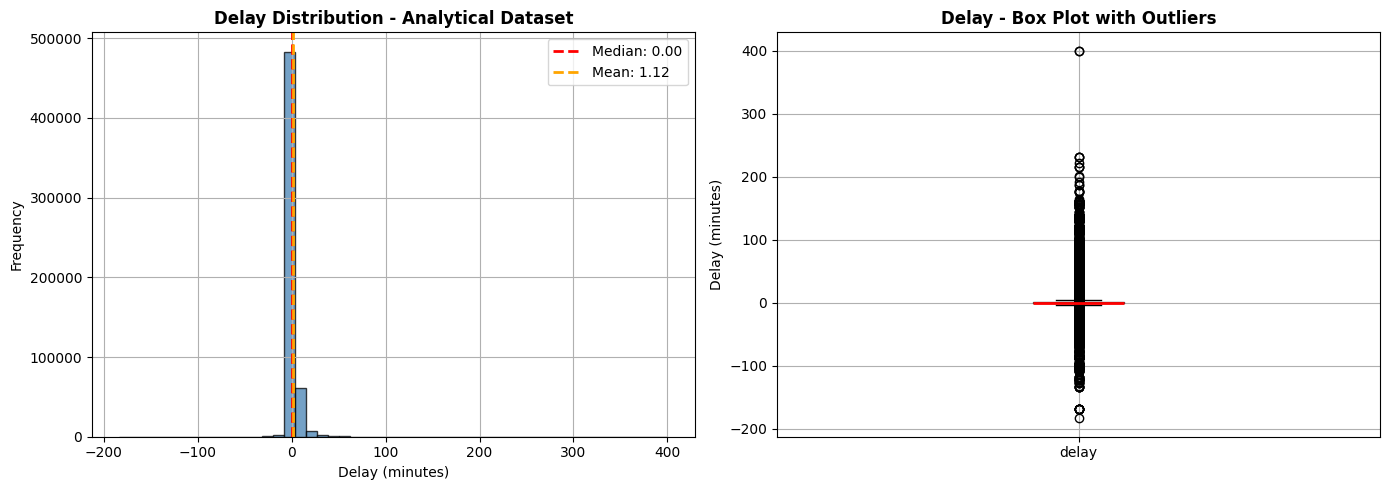

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delay.hist(bins=50, ax=axes[0], edgecolor="black", alpha=0.75, color="steelblue")
axes[0].axvline(delay.median(), color="red", linestyle="--", lw=2,
                label=f"Median: {delay.median():.2f}")
axes[0].axvline(delay.mean(), color="orange", linestyle="--", lw=2,
                label=f"Mean: {delay.mean():.2f}")
axes[0].set_xlabel("Delay (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Delay Distribution - Analytical Dataset", fontweight="bold")
axes[0].legend()

merged_df.boxplot(column="delay", vert=True, ax=axes[1], patch_artist=True,
                    boxprops=dict(facecolor="lightblue", alpha=0.7),
                    medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Delay (minutes)")
axes[1].set_title("Delay - Box Plot with Outliers", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_05/delay_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [35]:
# Outlier investigation
extreme_early = merged_df[merged_df["delay"] < -30]
extreme_late  = merged_df[merged_df["delay"] > 30]
print(f"Extreme early (< -30 min): {len(extreme_early):,} ({len(extreme_early)/len(merged_df)*100:.2f}%)")
print(f"Extreme late  (> 30 min):  {len(extreme_late):,} ({len(extreme_late)/len(merged_df)*100:.2f}%)")
if len(extreme_late):
    print("\nSample extreme late records:")
    display(extreme_late[["station_name","planned_timestamp","actual_timestamp","delay","closure_type"]].head(10))

Extreme early (< -30 min): 576 (0.10%)
Extreme late  (> 30 min):  2,631 (0.47%)

Sample extreme late records:


,station_name,planned_timestamp,actual_timestamp,delay,closure_type
137,Cardiff Central,2026-04-10 14:37:30,2026-04-10 15:14:00,36.5,planned
146,Cardiff Central,2026-04-10 19:25:00,2026-04-10 20:05:00,40.0,planned
695,Doncaster,2026-04-10 09:25:00,2026-04-10 13:00:00,215.0,planned
728,Garforth,2026-04-10 12:39:00,2026-04-10 13:27:00,48.0,planned
742,Hatfield and Stainforth,2026-04-10 14:52:30,2026-04-10 15:49:00,56.5,planned
751,Mexborough,2026-04-10 11:42:00,2026-04-10 13:55:00,133.0,planned
771,Micklefield,2026-04-10 22:23:00,2026-04-10 22:56:00,33.0,planned
1090,Severn Tunnel Junction,2026-04-10 13:40:30,2026-04-10 14:33:00,52.5,planned
1091,Severn Tunnel Junction,2026-04-10 14:15:00,2026-04-10 14:51:00,36.0,planned
1109,Vauxhall,2026-04-09 20:25:30,2026-04-09 21:12:00,46.5,planned


## 4. Predictor Distributions

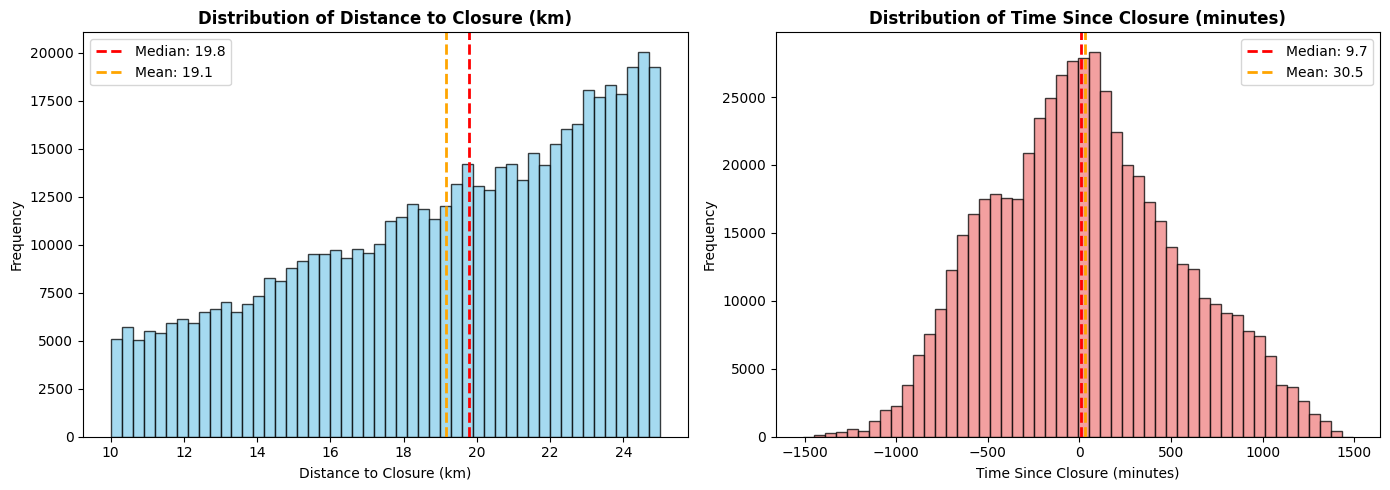

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color, label in [
    (axes[0], "distance_in_km", "skyblue", "Distance to Closure (km)"),
    (axes[1], "planned_time_diff", "lightcoral", "Time Since Closure (minutes)")
]:
    s = merged_df[col]
    ax.hist(s, bins=50, edgecolor="black", alpha=0.75, color=color)
    ax.axvline(s.median(), color="red", linestyle="--", lw=2, label=f"Median: {s.median():.1f}")
    ax.axvline(s.mean(), color="orange", linestyle="--", lw=2, label=f"Mean: {s.mean():.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of {label}", fontweight="bold")
    ax.legend()
plt.tight_layout()
plt.savefig("figures/eda_05/predictor_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Categorical Distributions

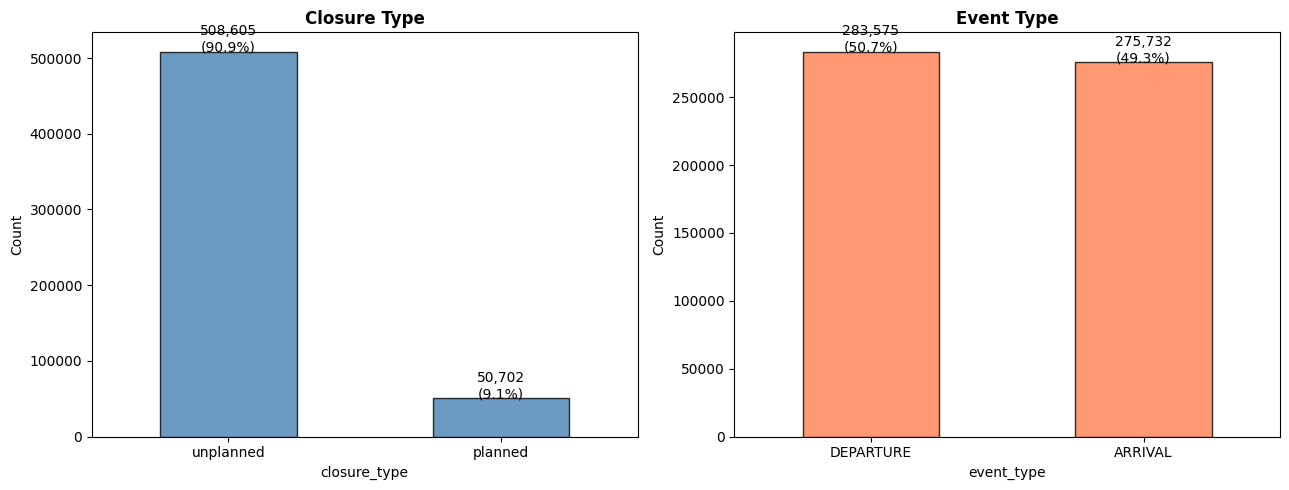

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct = merged_df["closure_type"].value_counts()
ct.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Closure Type", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(ct.values):
    axes[0].text(i, v + 10, f"{v:,}\n({v/len(merged_df)*100:.1f}%)", ha="center", fontsize=10)

et = merged_df["event_type"].value_counts()
et.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black", alpha=0.8)
axes[1].set_title("Event Type", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(et.values):
    axes[1].text(i, v + 10, f"{v:,}\n({v/len(merged_df)*100:.1f}%)", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("figures/eda_05/categorical_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

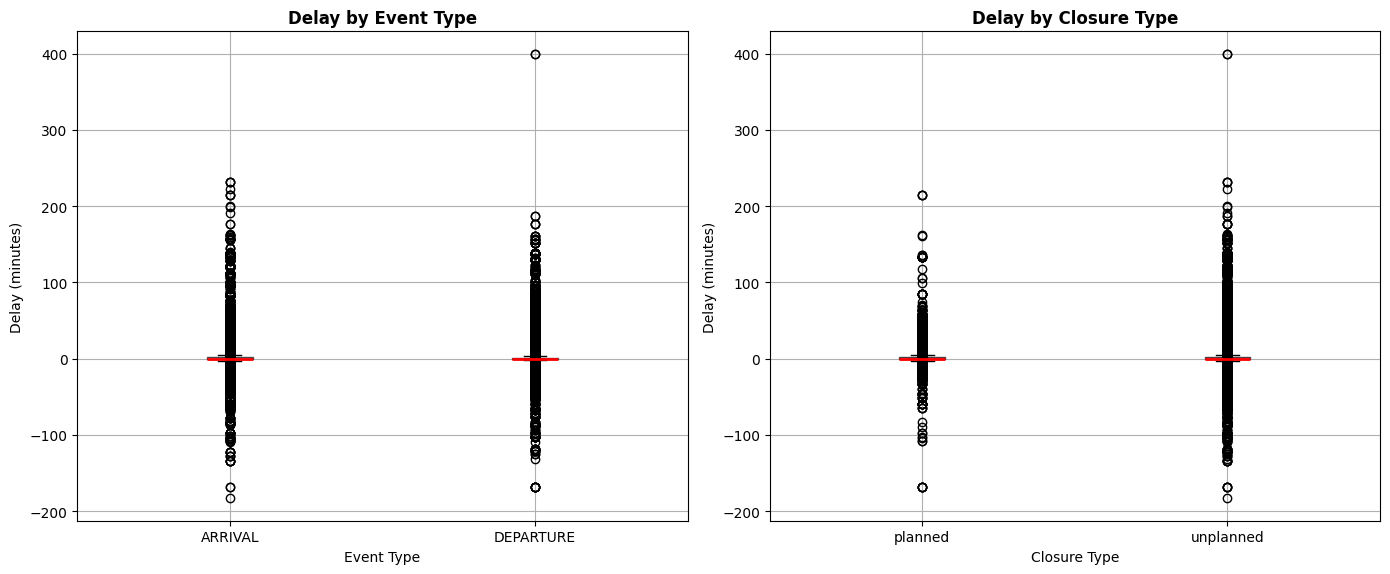


Mean delay by event type:
             mean  median    std   count
event_type                              
ARRIVAL     1.179     0.0  6.052  275732
DEPARTURE   1.066     0.0  6.008  283575

Mean delay by closure type:
               mean  median    std   count
closure_type                              
planned       1.207     0.0  6.237   50702
unplanned     1.114     0.0  6.009  508605


In [38]:
# Delay by categorical variables
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
merged_df.boxplot(column="delay", by="event_type", ax=axes[0], patch_artist=True,
                    boxprops=dict(facecolor="lightblue", alpha=0.7),
                    medianprops=dict(color="red", linewidth=2))
axes[0].set_title("Delay by Event Type", fontweight="bold")
axes[0].set_xlabel("Event Type")
axes[0].set_ylabel("Delay (minutes)")
plt.suptitle("")

merged_df.boxplot(column="delay", by="closure_type", ax=axes[1], patch_artist=True,
                    boxprops=dict(facecolor="lightcoral", alpha=0.7),
                    medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Delay by Closure Type", fontweight="bold")
axes[1].set_xlabel("Closure Type")
axes[1].set_ylabel("Delay (minutes)")
plt.suptitle("")
plt.tight_layout()
plt.savefig("figures/eda_05/delay_by_categories.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nMean delay by event type:")
print(merged_df.groupby("event_type")["delay"].agg(["mean","median","std","count"]).round(3))
print("\nMean delay by closure type:")
print(merged_df.groupby("closure_type")["delay"].agg(["mean","median","std","count"]).round(3))

## 6. Bivariate Relationships

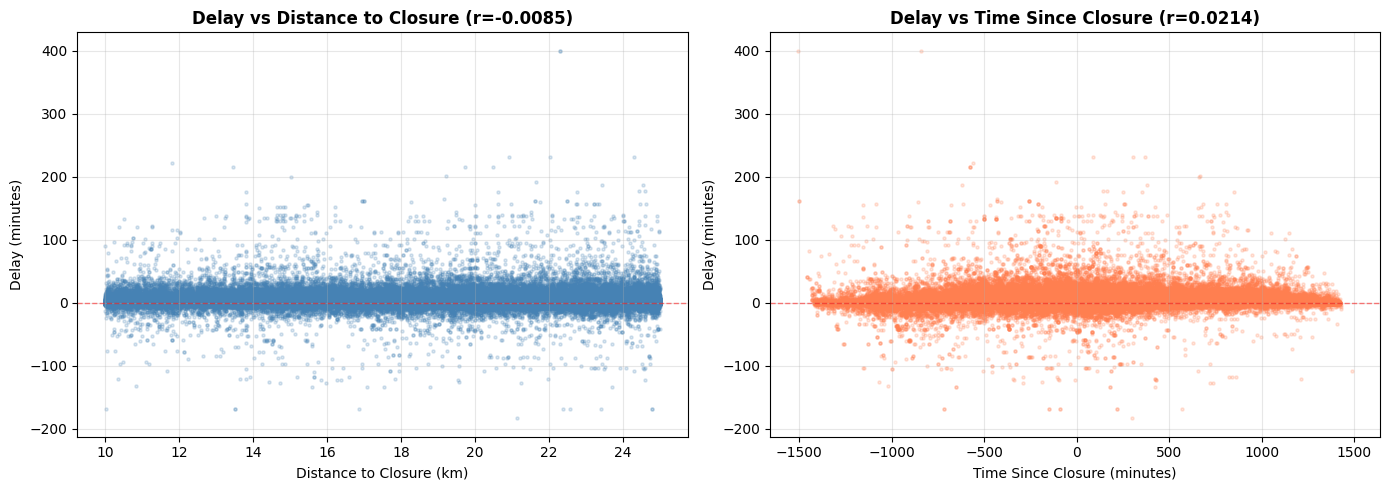

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color, xlabel in [
    (axes[0], "distance_in_km", "steelblue", "Distance to Closure (km)"),
    (axes[1], "planned_time_diff", "coral", "Time Since Closure (minutes)")
]:
    ax.scatter(merged_df[col], merged_df["delay"],
               alpha=0.2, s=5, color=color)
    ax.axhline(0, color="red", linestyle="--", lw=1, alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Delay (minutes)")
    corr = merged_df[[col,"delay"]].corr().iloc[0,1]
    ax.set_title(f"Delay vs {xlabel.split('(')[0].strip()} (r={corr:.4f})", fontweight="bold")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/eda_05/scatter_delay_vs_predictors.png", dpi=200, bbox_inches="tight")
plt.show()

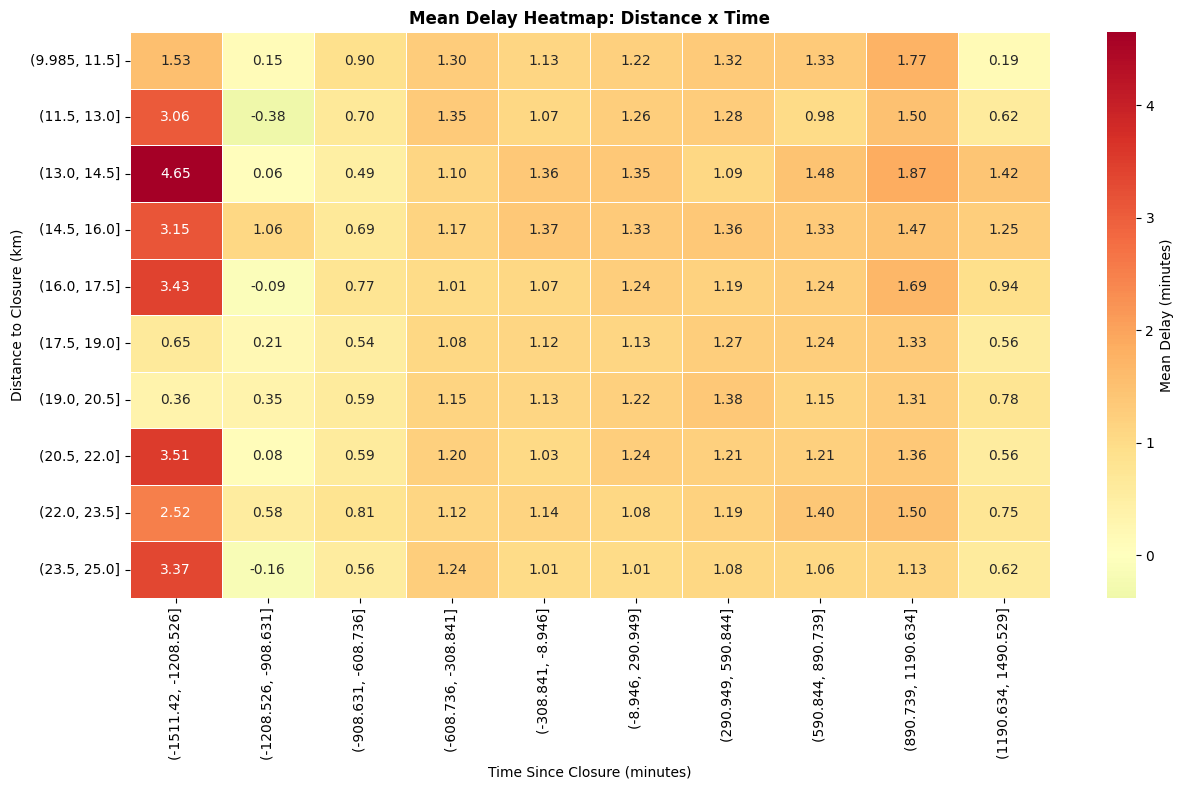

In [40]:
# Distance x time heatmap
hm = merged_df.copy()
hm["dist_bin"] = pd.cut(hm["distance_in_km"], bins=10)
hm["time_bin"] = pd.cut(hm["planned_time_diff"], bins=10)
pivot = hm.pivot_table(values="delay", index="dist_bin", columns="time_bin", aggfunc="mean")

plt.figure(figsize=(13, 8))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0,
            cbar_kws={"label": "Mean Delay (minutes)"}, linewidths=0.5)
plt.xlabel("Time Since Closure (minutes)")
plt.ylabel("Distance to Closure (km)")
plt.title("Mean Delay Heatmap: Distance x Time", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_05/heatmap_distance_time.png", dpi=200, bbox_inches="tight")
plt.show()

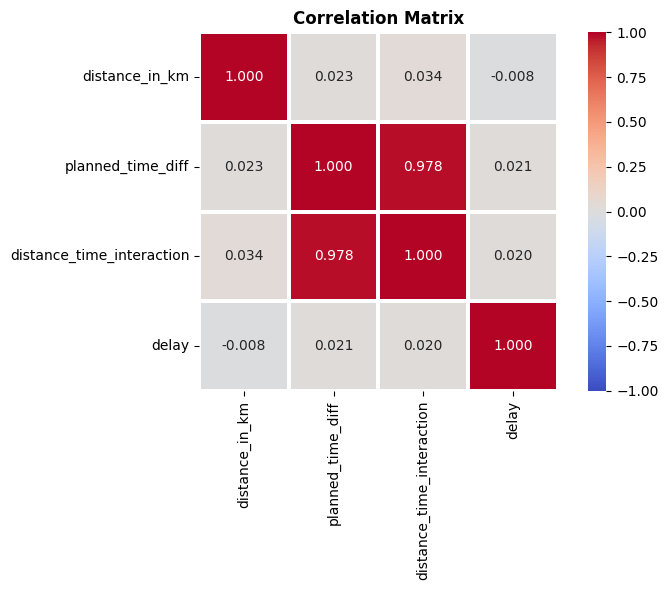


Correlation with delay:
distance_in_km              -0.008477
distance_time_interaction    0.019946
planned_time_diff            0.021427
Name: delay, dtype: float64


In [41]:
# Correlation matrix
numeric_cols = ["distance_in_km", "planned_time_diff", "distance_time_interaction", "delay"]
corr_matrix = merged_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=1.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_05/correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print("\nCorrelation with delay:")
print(corr_matrix["delay"].drop("delay").sort_values())

## 7. Temporal Patterns

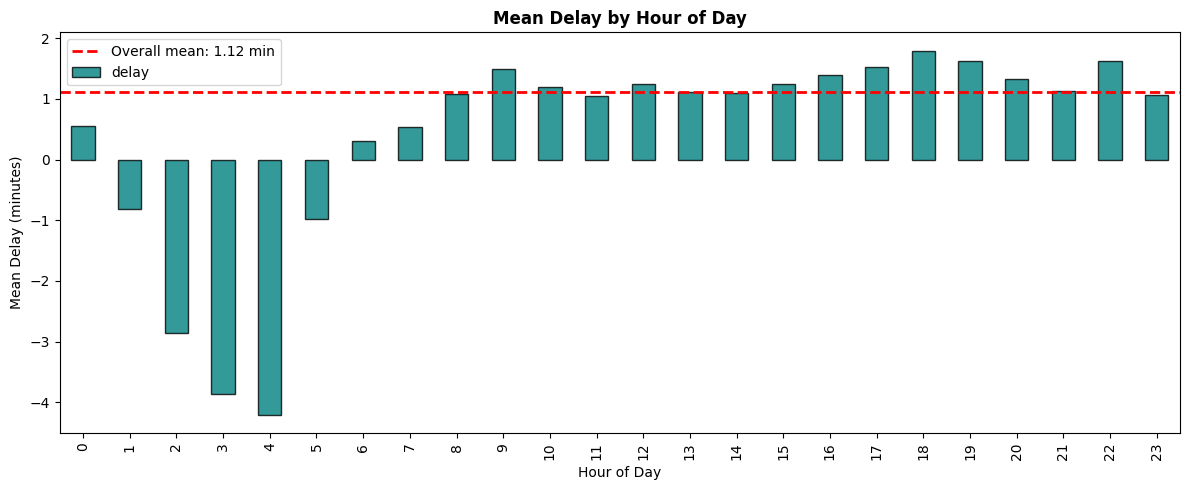

In [42]:
merged_df["hour"] = merged_df["planned_timestamp"].dt.hour
hourly = merged_df.groupby("hour")["delay"].mean()

plt.figure(figsize=(12, 5))
hourly.plot(kind="bar", color="teal", edgecolor="black", alpha=0.8)
plt.xlabel("Hour of Day")
plt.ylabel("Mean Delay (minutes)")
plt.title("Mean Delay by Hour of Day", fontweight="bold")
plt.axhline(merged_df["delay"].mean(), color="red", linestyle="--", lw=2,
            label=f"Overall mean: {merged_df['delay'].mean():.2f} min")
plt.legend()
plt.tight_layout()
plt.savefig("figures/eda_05/delay_by_hour.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Spatial Patterns

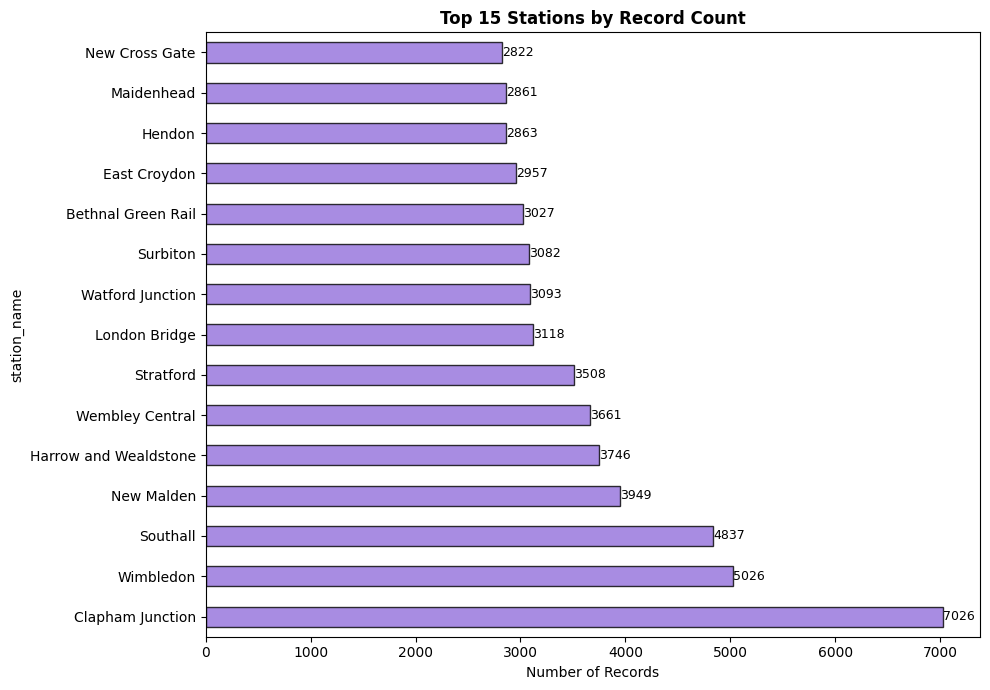

Top 15 stations: 55,576 rows (9.9% of total)


In [43]:
top_stations = merged_df["station_name"].value_counts().head(15)
plt.figure(figsize=(10, 7))
top_stations.plot(kind="barh", color="mediumpurple", edgecolor="black", alpha=0.8)
plt.xlabel("Number of Records")
plt.title("Top 15 Stations by Record Count", fontweight="bold")
for i, v in enumerate(top_stations.values):
    plt.text(v + 0.5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/eda_05/top_stations.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Top 15 stations: {top_stations.sum():,} rows ({top_stations.sum()/len(merged_df)*100:.1f}% of total)")

Unique closures: 1056
Mean rows per closure:   529.6
Median rows per closure: 272.0
Max rows per closure:    6794


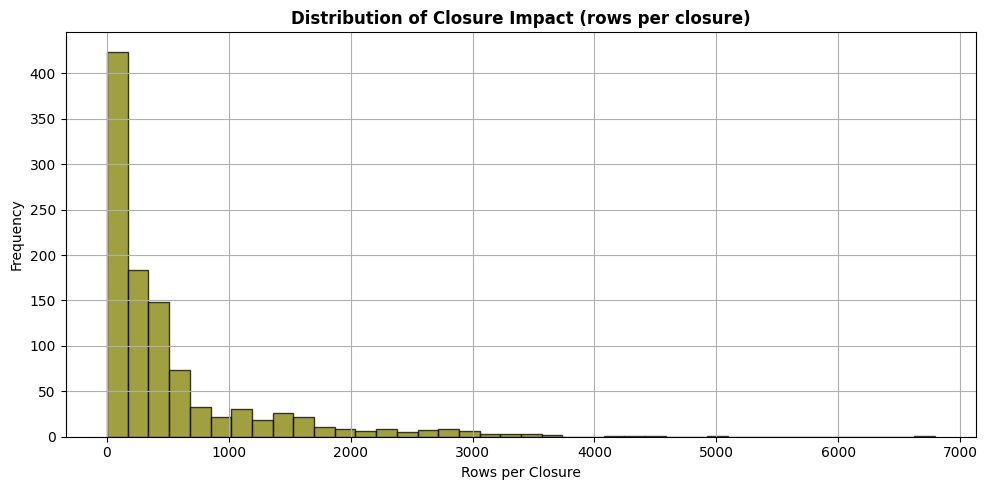

In [44]:
# Closure impact distribution
closure_counts = merged_df.groupby("closure_id").size().sort_values(ascending=False)
print(f"Unique closures: {len(closure_counts)}")
print(f"Mean rows per closure:   {closure_counts.mean():.1f}")
print(f"Median rows per closure: {closure_counts.median():.1f}")
print(f"Max rows per closure:    {closure_counts.max()}")

plt.figure(figsize=(10, 5))
closure_counts.hist(bins=40, edgecolor="black", alpha=0.75, color="olive")
plt.xlabel("Rows per Closure")
plt.ylabel("Frequency")
plt.title("Distribution of Closure Impact (rows per closure)", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_05/closure_impact.png", dpi=200, bbox_inches="tight")
plt.show()

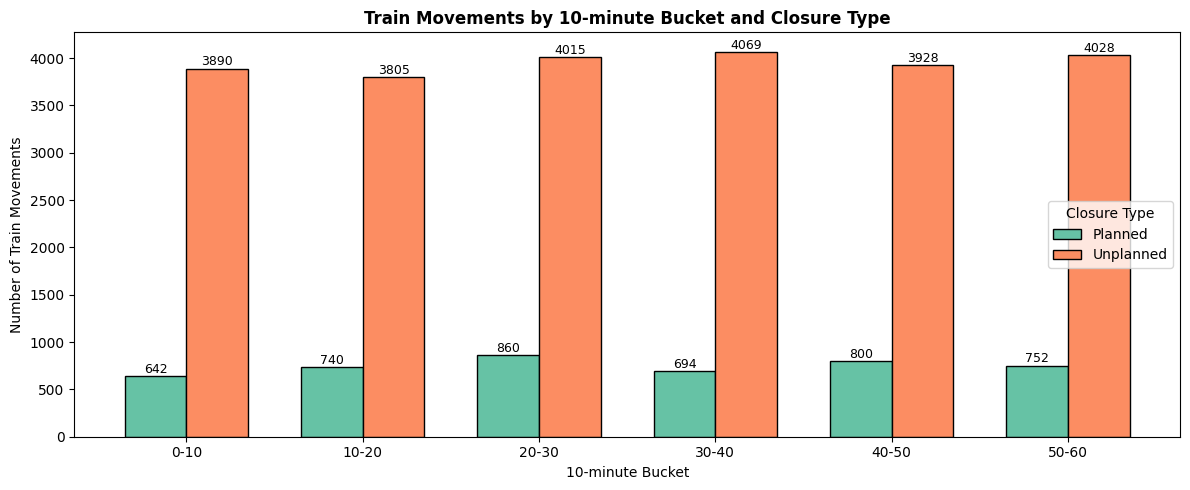

In [45]:
# 10-minute bucket analysis
merged_df["time_bucket"] = pd.cut(
    merged_df["planned_time_diff"],
    bins=[0, 10, 20, 30, 40, 50, 60],
    labels=["0-10", "10-20", "20-30", "30-40", "40-50", "50-60"]
)
bucket_ct = merged_df.groupby(["time_bucket", "closure_type"]).size().unstack(fill_value=0)

# Ensure closure types appear in consistent order
cols = ["planned", "unplanned"]
bucket_plot = bucket_ct[cols]

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(bucket_plot.index))  # bucket positions
width = 0.35

# Bars
bars1 = ax.bar(x - width/2, bucket_plot["planned"], width,
               label="Planned", color="#66c2a5", edgecolor="black")
bars2 = ax.bar(x + width/2, bucket_plot["unplanned"], width,
               label="Unplanned", color="#fc8d62", edgecolor="black")

# Add count labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
            f"{int(height)}", ha="center", va="bottom", fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
            f"{int(height)}", ha="center", va="bottom", fontsize=9)

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(bucket_plot.index)
ax.set_xlabel("10-minute Bucket")
ax.set_ylabel("Number of Train Movements")
ax.set_title("Train Movements by 10-minute Bucket and Closure Type", fontweight="bold")
ax.legend(title="Closure Type")

plt.tight_layout()
plt.show()




In [46]:
bucket_vs = merged_df.groupby(["time_bucket", "validity_status"]).size().unstack(fill_value=0)
print("Train Moments by 10-minute bucket and validity status:")
print(bucket_vs.to_string())
bucket_vs["Total"] = bucket_vs.sum(axis=1)
print(f"\nProportion per bucket:\n{(bucket_vs['Total'] / bucket_vs['Total'].sum() * 100).round(1).to_string()}")

Train Moments by 10-minute bucket and validity status:
validity_status  active  planned  suspended
time_bucket                                
0-10                  0      546       3986
10-20                 0      605       3940
20-30                 0      686       4189
30-40                 0      572       4191
40-50                 4      625       4099
50-60                 0      626       4154

Proportion per bucket:
time_bucket
0-10     16.1
10-20    16.1
20-30    17.3
30-40    16.9
40-50    16.8
50-60    16.9


In [47]:
# 10-minute bucket analysis
merged_df["time_bucket"] = pd.cut(
    merged_df["closure_start_time"].dt.hour * 60 + merged_df["closure_start_time"].dt.minute,
    bins=[0, 10, 20, 30, 40, 50, 60],
    labels=["0-10", "10-20", "20-30", "30-40", "40-50", "50-60"]
)
bucket_ct = merged_df.groupby(["time_bucket", "variation_status"]).size().unstack(fill_value=0)
print("Train Moments by 10-minute bucket and variation status:")
print(bucket_ct.to_string())
bucket_ct["Total"] = bucket_ct.sum(axis=1)
print(f"\nProportion per bucket:\n{(bucket_ct['Total'] / bucket_ct['Total'].sum() * 100).round(1).to_string()}")

Train Moments by 10-minute bucket and variation status:
variation_status  EARLY  LATE  ON TIME
time_bucket                           
0-10                398   844      647
10-20               737  1496     1449
20-30               206   560      294
30-40               323   704      430
40-50               360   868      582
50-60               551   929      745

Proportion per bucket:
time_bucket
0-10     15.6
10-20    30.4
20-30     8.7
30-40    12.0
40-50    14.9
50-60    18.4


## 9. Save Analytical Dataset

In [48]:
merged_df.to_parquet("./data/processed/road_train_moments_dataset.parquet", index=False)
print(f"Saved road_train_moments dataset: {len(merged_df):,} rows")
print("Path: data/processed/road_train_moments_dataset.parquet")
print()
print("Column summary:")
merged_df.info()

Saved road_train_moments dataset: 559,307 rows
Path: data/processed/road_train_moments_dataset.parquet

Column summary:
<class 'pandas.DataFrame'>
RangeIndex: 559307 entries, 0 to 559306
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   closure_id                 559307 non-null  str           
 1   closure_type               559307 non-null  str           
 2   validity_status            559307 non-null  str           
 3   cause_type                 559307 non-null  str           
 4   distance_in_km             559307 non-null  float64       
 5   station_name               559307 non-null  str           
 6   stanox                     559307 non-null  str           
 7   closure_start_time         559307 non-null  datetime64[us]
 8   actual_timestamp           559307 non-null  datetime64[ms]
 9   planned_timestamp          559307 non-null  datetime64[ms]
 10  planned